# K-Means Clustering

## Introduction

K-Means is an unsupervised learning algorithm that partitions data into K clusters. Each cluster is represented by its centroid (mean), and each data point belongs to the nearest centroid.

**Why use it?**
- Groups similar data points together without labeled data
- Discovers patterns and structure in data
- Fast and scalable for large datasets
- Works well when clusters are roughly spherical and similar in size

## How K-Means Works

**Algorithm:**
1. **Initialize:** Randomly select K data points as initial centroids
2. **Assign:** Assign each data point to the nearest centroid (using Euclidean distance)
3. **Update:** Calculate new centroid for each cluster (mean of all points in cluster)
4. **Repeat:** Steps 2-3 until centroids stop moving (convergence)

**Visual Process:**
- Iteration 0: Random centroids placed
- Iteration 1: Points assigned to nearest centroid
- Iteration 2: Centroids move to cluster centers
- ... repeat until stable

**Distance Formula:** $d = \sqrt{\sum_{i=1}^{n} (x_i - c_i)^2}$ (Euclidean distance)

## Choosing K

**Elbow Method:**
- Plot inertia (sum of squared distances) vs. K
- Look for "elbow" point where inertia stops decreasing rapidly
- K at the elbow is often optimal

**Silhouette Score:**
- Measures how similar points are to their own cluster vs. other clusters
- Range: -1 to 1 (higher is better)
- Choose K with highest average silhouette score

**Domain Knowledge:**
- Use business requirements or problem constraints
- Sometimes you know how many groups should exist

## Advantages & Disadvantages

**Advantages:**
- Fast and scalable (O(n*k*i) where i = iterations)
- Simple to implement and understand
- Works well with large datasets
- Easy to interpret results

**Disadvantages:**
- Must specify K beforehand
- Sensitive to initial centroid placement (may converge to local minimum)
- Assumes clusters are spherical and roughly equal size
- Not ideal for non-globular clusters or varying cluster sizes
- Outliers can distort centroids

## Best Practices

1. **Standardize Data:** Scale all features to same range (0-1 or mean=0, std=1) before clustering
2. **Try Multiple Runs:** K-Means can get stuck in local minima. Run multiple times with different initializations and pick best result
3. **Use K-Means++:** Better initialization strategy than random selection. Reduces chance of poor local minima
4. **Check Convergence:** Monitor if centroids have stopped moving
5. **Outlier Handling:** Remove extreme outliers before clustering as they affect centroids

## Common Issues

| Issue | Cause | Solution |
|-------|-------|----------|
| Different results each run | Random initialization | Use `n_init` parameter to try multiple initializations |
| Poor clusters | Wrong K value | Use Elbow method or Silhouette score |
| Unbalanced clusters | Data characteristics | Try normalization or use K-Medoids |
| Slow convergence | High dimensions | Reduce dimensions with PCA first |

## Summary

**Key Takeaways:**
- K-Means partitions data into K clusters by minimizing distance to centroids
- Simple, fast, and scalable for large datasets
- Requires specifying K (use Elbow method or Silhouette score)
- Always standardize data before clustering
- Run multiple times to avoid local minima
- Best for roughly spherical, similar-sized clusters

**When to Use:**
- Customer segmentation
- Image compression
- Document clustering
- Quick exploratory clustering

**Alternatives:**
- **Hierarchical Clustering:** Better for different cluster sizes
- **DBSCAN:** For non-globular clusters and variable shapes
- **Gaussian Mixture Models:** Probabilistic approach, more flexible

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
df=pd.read_csv("./Data/income.csv")
df.head()

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


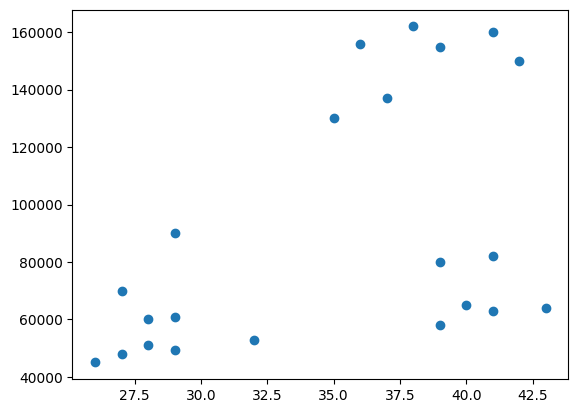

In [30]:
plt.scatter(df["Age"],df['Income'])

In [31]:
km=KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [32]:
y_predicted=km.fit_predict(df[["Age","Income"]])
y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [33]:
df["Cluster"]=y_predicted
df.head()

,Name,Age,Income,Cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


## K-Means Clustering Visualization (Without Preprocessing)

In this approach, the dataset is directly used for clustering **without any preprocessing** such as scaling or normalization. Because of this, the clustering may not be very accurate and can produce **errors or improper groupings**.

### Step 1: Divide Data Based on Clusters

The dataset is divided into three groups based on the `Cluster` column:

- `df1` → contains all data points where Cluster = 0  
- `df2` → contains all data points where Cluster = 1  
- `df3` → contains all data points where Cluster = 2  

This separation helps in visualizing how K-Means has grouped the data.

---

### Step 2: Plot the Clusters

A scatter plot is used to visualize the clusters:

- `Age` is taken on the X-axis  
- `Income` is taken on the Y-axis  

Each cluster is shown with a different color:

- Cluster 0 → Green  
- Cluster 1 → Red  
- Cluster 2 → Black  

---

### Step 3: Add Labels and Legend

- X-axis is labeled as Age  
- Y-axis is labeled as Income  
- A legend is added to identify different clusters  

---

## Important Note

Since no preprocessing (like feature scaling) is applied, K-Means may divide the data incorrectly. Features with larger values (like Income) can dominate the clustering process, leading to less accurate clusters and possible errors in grouping.

/var/folders/fy/sj43z68s65g67n7z6vwkdtrw0000gn/T/ipykernel_10413/2241796581.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


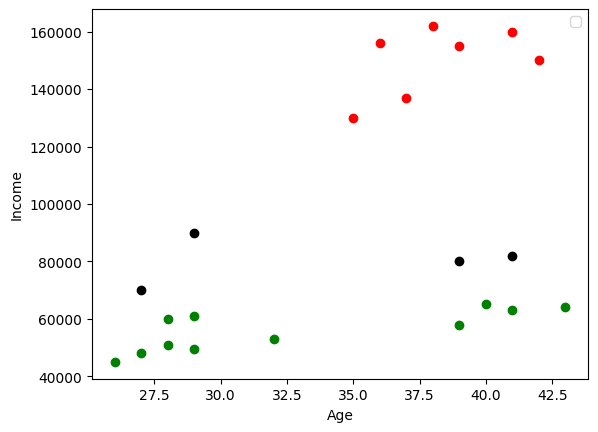

In [34]:
df1=df[df["Cluster"]==0]
df2=df[df["Cluster"]==1]
df3=df[df["Cluster"]==2]

plt.scatter(df1.Age,df1.Income,color="green")
plt.scatter(df2.Age,df2.Income,color="red")
plt.scatter(df3.Age,df3.Income,color="black")

plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()

In [35]:
scaler=MinMaxScaler()
scaler.fit(df[["Income"]])
df.Income=scaler.transform(df[["Income"]])
df.head()

,Name,Age,Income,Cluster
0,Rob,27,0.213675,2
1,Michael,29,0.384615,2
2,Mohan,29,0.136752,0
3,Ismail,28,0.128205,0
4,Kory,42,0.897436,1


In [36]:
scaler.fit(df[["Age"]])
df.Age=scaler.transform(df[["Age"]])
df.head()

,Name,Age,Income,Cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [37]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df[["Age","Income"]])
y_predicted

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [38]:
df["Cluster"]=y_predicted
df.head()

,Name,Age,Income,Cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


## K-Means Clustering Visualization (With MinMaxScaler)

In this approach, **MinMaxScaler** is applied before using K-Means. This scales all features (like Age and Income) into a common range (usually 0 to 1), ensuring that no single feature dominates the clustering process.

---

### Step 1: Apply MinMaxScaler

Before clustering, the dataset is scaled using MinMaxScaler:

- Converts all feature values into a range between 0 and 1  
- Maintains the relative differences between data points  
- Prevents large-value features (like Income) from dominating smaller ones (like Age)  

This step improves the accuracy of clustering.

---

### Step 2: Apply K-Means Clustering

After scaling:

- K-Means is applied on the transformed data  
- Data points are grouped into clusters based on similarity  
- Each point is assigned a cluster label (0, 1, 2, etc.)  

---

### Step 3: Divide Data Based on Clusters

The dataset is divided into groups using the `Cluster` column:

- `df1` → Cluster = 0  
- `df2` → Cluster = 1  
- `df3` → Cluster = 2  

This helps in visualizing each cluster separately.

---

### Step 4: Plot the Clusters

A scatter plot is used for visualization:

- X-axis → Age  
- Y-axis → Income  

Each cluster is represented using different colors:

- Cluster 0 → Green  
- Cluster 1 → Red  
- Cluster 2 → Black  

---

### Step 5: Add Labels and Legend

- X-axis labeled as Age  
- Y-axis labeled as Income  
- Legend is added to identify clusters  

---

## Important Note

By using MinMaxScaler, all features contribute equally to the clustering process. This results in **more accurate and well-separated clusters** compared to using raw data without preprocessing.

In [39]:
km.cluster_centers_

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

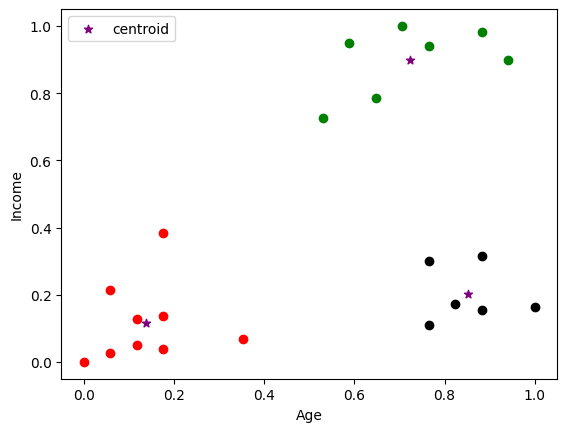

In [41]:
df1=df[df["Cluster"]==0]
df2=df[df["Cluster"]==1]
df3=df[df["Cluster"]==2]

plt.scatter(df1.Age,df1.Income,color="green")
plt.scatter(df2.Age,df2.Income,color="red")
plt.scatter(df3.Age,df3.Income,color="black")
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color="purple",marker="*",label="centroid")

plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()